In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

dtypes = {
    'user_id':       'int32',
    'item_id':       'int32',
    'category_id':   'int32',
    'behavior_type': 'category'
}
col_names = ['user_id', 'item_id', 'category_id','behavior_type']
data_path = Path.cwd().parent / 'UserBehavior_cleaning.csv'
chunks = []
chunk_size = 5_000_000

for chunk in pd.read_csv(
    data_path,
    header = 0,
    usecols=col_names,
    dtype=dtypes,
    chunksize=chunk_size,
):
    chunks.append(chunk[['user_id', 'item_id', 'category_id','behavior_type']])

df = pd.concat(chunks, ignore_index=True)
print(df.head(5))
print(f'数据加载完成，共{len(df):,}条记录')

   user_id  item_id  category_id behavior_type
0        1  2576651       149192            pv
1        1  3830808      4181361            pv
2        1  4365585      2520377            pv
3        1  4606018      2735466            pv
4        1   230380       411153            pv
数据加载完成，共86,870,392条记录


In [4]:
#次数口径
count_behavior = df.groupby('behavior_type',observed= False).size()

print(f'浏览行为次数：{count_behavior["pv"]}')
print(f'加购行为次数：{count_behavior["cart"]}')
print(f'收藏行为次数：{count_behavior["fav"]}')
print(f'购买行为次数：{count_behavior["buy"]}')

pv_to_fav_cart_cb = (count_behavior['fav'] + count_behavior['cart']) / count_behavior['pv']*100
fav_cart_to_buy_cb = count_behavior['buy'] / (count_behavior['fav'] + count_behavior['cart'])*100
pv_to_fav_cb = count_behavior['fav'] / count_behavior['pv']*100
pv_to_cart_cb = count_behavior['cart'] / count_behavior['pv']*100
pv_to_buy_cb = count_behavior['buy'] / count_behavior['pv']*100
fav_to_buy_cb = count_behavior['buy'] / count_behavior['fav']*100
cart_to_buy_cb = count_behavior['buy'] / count_behavior['cart']*100

print(f'浏览->收藏/加购：{pv_to_fav_cart_cb:.2f}%')
print(f'收藏/加购->购买：{fav_cart_to_buy_cb:.2f}%')
print(f'浏览->收藏：{pv_to_fav_cb:.2f}%')
print(f'浏览->加购：{pv_to_cart_cb:.2f}%')
print(f'浏览->购买：{pv_to_buy_cb:.2f}%')
print(f'收藏->购买：{fav_to_buy_cb:.2f}%')
print(f'加购->购买：{cart_to_buy_cb:.2f}%')

#客户口径
# 找出真正经历了 pv→cart/fav→buy 完整路径的用户
user_behaviors = df.groupby("user_id")["behavior_type"].apply(set)

has_pv = user_behaviors[user_behaviors.apply(lambda x: "pv" in x)].index
has_cart = user_behaviors[user_behaviors.apply(lambda x: "cart" in x)].index
has_fav = user_behaviors[user_behaviors.apply(lambda x: 'fav' in x)].index
has_buy = user_behaviors[user_behaviors.apply(lambda x: "buy" in x)].index

# 严格漏斗：有pv的用户中，有多少也有cart，进而有buy
pv_users = set(has_pv)
cart_users = set(has_cart) & pv_users  # 有pv且有cart
fav_users = set(has_fav) & pv_users
fav_cart_users = fav_users | cart_users
buy_users = set(has_buy) & fav_cart_users  # 有pv且有cart或fav且有buy

pv_to_fav_cart = len(fav_cart_users) / len(pv_users)
fav_cart_to_buy = len(buy_users) / len(fav_cart_users)

# 识别用户流失节点（计算各行为转换的流失率）
# PV → 加购/收藏 的流失
pv_users_count = len(pv_users)
fav_cart_users_count = len(fav_cart_users)
pv_to_cart_fav_drop = pv_users_count - fav_cart_users_count
pv_to_cart_fav_drop_rate = (pv_to_cart_fav_drop / pv_users_count * 100) if pv_users_count > 0 else 0

print(f'浏览 → 加购/收藏')
print(f'  浏览用户数: {pv_users_count:,}')
print(f'  加购/收藏用户数: {fav_cart_users_count:,}')
print(f'  流失用户数: {pv_to_cart_fav_drop:,}')
print(f'  流失率: {pv_to_cart_fav_drop_rate:.2f}%')

# 加购/收藏 → 购买 的流失
buy_users_count = len(buy_users)
cart_fav_to_buy_drop = fav_cart_users_count - buy_users_count
cart_fav_to_buy_drop_rate = (cart_fav_to_buy_drop / fav_cart_users_count * 100) if fav_cart_users_count > 0 else 0

print(f'\n加购/收藏 → 购买')
print(f'  加购/收藏用户数: {fav_cart_users_count:,}')
print(f'  购买用户数: {buy_users_count:,}')
print(f'  流失用户数: {cart_fav_to_buy_drop:,}')
print(f'  流失率: {cart_fav_to_buy_drop_rate:.2f}%')

# 识别最大流失节点
max_drop_rate = max(pv_to_cart_fav_drop_rate, cart_fav_to_buy_drop_rate)
if max_drop_rate == pv_to_cart_fav_drop_rate:
    critical_point = 'PV浏览 → 加购/收藏'
else:
    critical_point = '加购/收藏 → 购买'

print(f'\n========== 关键发现 ==========')
print(f'最大流失节点: {critical_point}')
print(f'最大流失率: {max_drop_rate:.2f}%')

#其他节点数据
fav_buy_users = set(has_buy) & fav_users
cart_buy_users = cart_users & set(has_buy)
total_buy_users = set(has_buy) & pv_users
pv_buy_users = total_buy_users - buy_users

pv_to_buy = (len(pv_buy_users) / len(total_buy_users)*100) if len(pv_users) > 0 else 0
print(f'直接购买的用户数（跳过收藏和加购的用户）{len(pv_buy_users)}')
print(f'在总购买用户中的占比{pv_to_buy:.2f}%')

pv_to_fav = (len(fav_users) / len(pv_users)*100) if len(pv_users) > 0 else 0
pv_to_cart = (len(cart_users) / len(pv_users)*100) if len(pv_users) > 0 else 0
fav_to_buy = (len(fav_buy_users) / len(fav_users)*100) if len(fav_users) > 0 else 0
cart_to_buy = (len(cart_buy_users) / len(cart_users)*100) if len(cart_users) > 0 else 0
print(f'浏览到收藏的转化率：{pv_to_buy:.2f}%')
print(f'浏览到加购的转化率：{pv_to_cart:.2f}%')
print(f'收藏到购买的转化率：{fav_to_buy:.2f}%')
print(f'加购到购买的转化率：{cart_to_buy:.2f}%')


浏览行为次数：77887714
加购行为次数：4752175
收藏行为次数：2479677
购买行为次数：1750826
浏览->收藏/加购：9.28%
收藏/加购->购买：24.21%
浏览->收藏：3.18%
浏览->加购：6.10%
浏览->购买：2.25%
收藏->购买：70.61%
加购->购买：36.84%
浏览 → 加购/收藏
  浏览用户数: 983,847
  加购/收藏用户数: 830,468
  流失用户数: 153,379
  流失率: 15.59%

加购/收藏 → 购买
  加购/收藏用户数: 830,468
  购买用户数: 551,571
  流失用户数: 278,897
  流失率: 33.58%

========== 关键发现 ==========
最大流失节点: 加购/收藏 → 购买
最大流失率: 33.58%
直接购买的用户数（跳过收藏和加购的用户）75079
在总购买用户中的占比11.98%
浏览到收藏的转化率：11.98%
浏览到加购的转化率：71.82%
收藏到购买的转化率：67.50%
加购到购买的转化率：68.20%


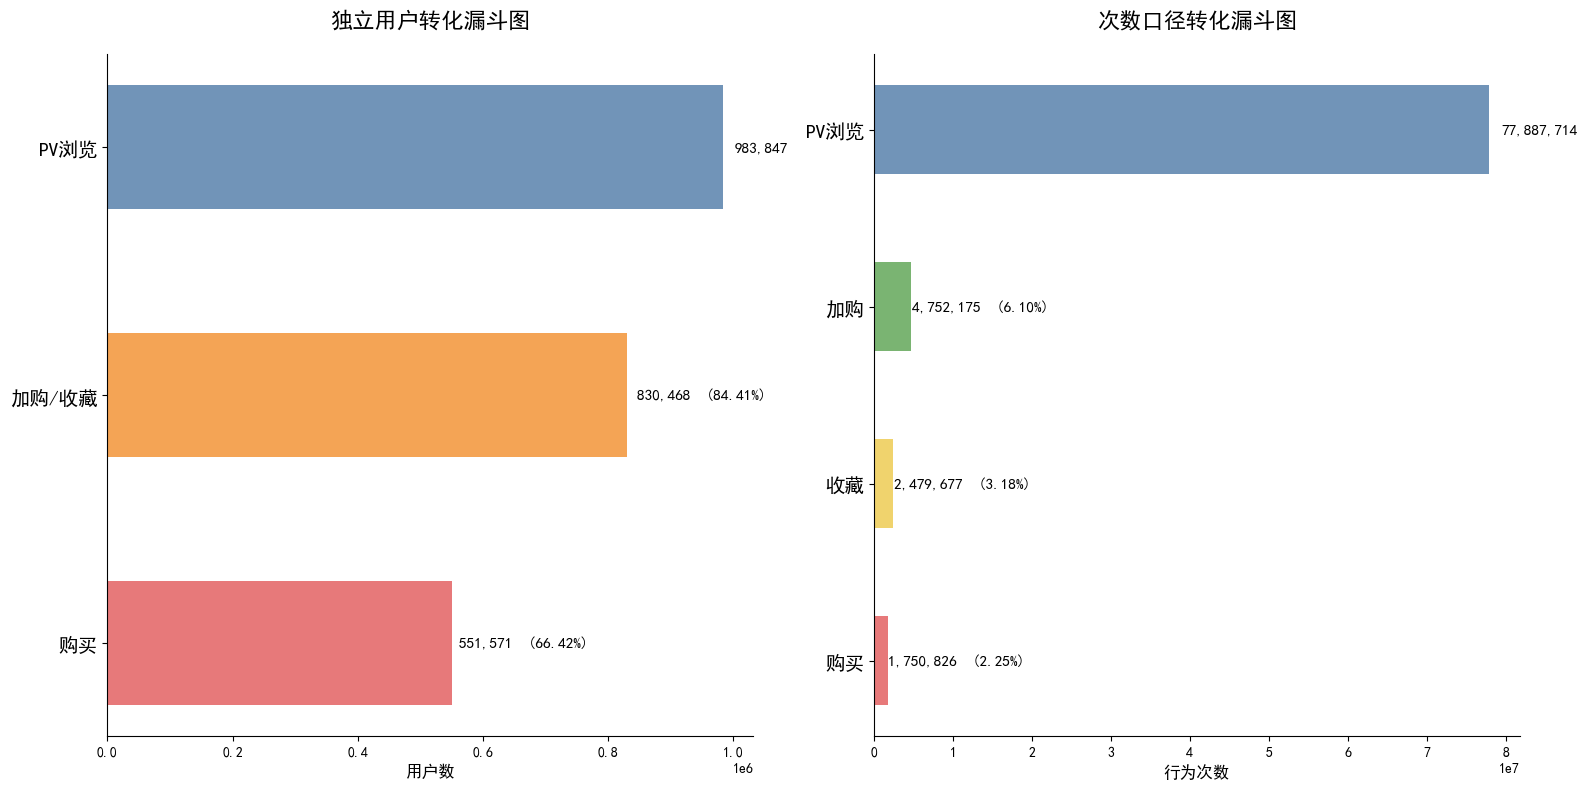

In [7]:
# 绘制漏斗分析图
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 准备漏斗数据（加购和收藏合并为一层）
stages = ['PV浏览', '加购/收藏', '购买']
user_counts = [pv_users_count, fav_cart_users_count, buy_users_count]

# 计算转化率标签
conversion_labels = ['100%']
for i in range(1, len(stages)):
    rate = (user_counts[i] / user_counts[i-1]) * 100
    conversion_labels.append(f'{rate:.2f}%')

# 创建画布 - 两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ========== 左图：独立用户转化漏斗图 ==========
# 准备客户口径数据
colors = ['#4E79A7', '#F28E2B', '#E15759']
y_pos = np.arange(len(stages))
bars = ax1.barh(y_pos, user_counts, color=colors, alpha=0.8, height=0.5)

# 在条形图右侧添加用户数和转化率标签（写在条形图外）
for i, (bar, count, label) in enumerate(zip(bars, user_counts, conversion_labels)):
    width = bar.get_width()
    # 将用户数和转化率写在一起放在条形图外
    text_label = f'{count:,.0f}' if i == 0 else f'{count:,.0f}  ({label})'
    ax1.text(width * 1.02, bar.get_y() + bar.get_height()/2, 
            text_label, 
            ha='left', va='center', fontsize=11, fontweight='bold')

# 设置图表
ax1.set_yticks(y_pos)
ax1.set_yticklabels(stages, fontsize=14)
ax1.set_xlabel('用户数', fontsize=12)
ax1.set_title('独立用户转化漏斗图', fontsize=16, fontweight='bold', pad=20)
ax1.invert_yaxis()  # 从上到下显示

# 移除顶部和右侧边框
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ========== 右图：次数口径转化漏斗图 ==========
# 准备次数口径数据
count_stages = ['PV浏览', '加购', '收藏', '购买']
count_values = [count_behavior['pv'], count_behavior['cart'], count_behavior['fav'], count_behavior['buy']]

# 计算次数口径的转化率标签
count_conversion_labels = ['100%']
for i in range(1, len(count_stages)):
    # 从浏览到各行为的转化率
    rate = (count_values[i] / count_values[0]) * 100
    count_conversion_labels.append(f'{rate:.2f}%')

# 绘制次数口径漏斗图
count_colors = ['#4E79A7', '#59A14F', '#EDC948', '#E15759']
y_pos_count = np.arange(len(count_stages))
bars_count = ax2.barh(y_pos_count, count_values, color=count_colors, alpha=0.8, height=0.5)

# 在条形图右侧添加次数和转化率标签（写在条形图外）
for i, (bar, count, label) in enumerate(zip(bars_count, count_values, count_conversion_labels)):
    width = bar.get_width()
    # 将次数和转化率写在一起放在条形图外
    text_label = f'{count:,.0f}' if i == 0 else f'{count:,.0f}  ({label})'
    ax2.text(width * 1.02, bar.get_y() + bar.get_height()/2, 
            text_label, 
            ha='left', va='center', fontsize=11, fontweight='bold')

# 设置图表
ax2.set_yticks(y_pos_count)
ax2.set_yticklabels(count_stages, fontsize=14)
ax2.set_xlabel('行为次数', fontsize=12)
ax2.set_title('次数口径转化漏斗图', fontsize=16, fontweight='bold', pad=20)
ax2.invert_yaxis()

# 移除顶部和右侧边框
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../conversion_funnel.png', dpi=300, bbox_inches='tight')
plt.show()